# Scenario 2: Dimensionality Reduction using PCA

## Import libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

## Load dataset

In [ ]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## Standardize features

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

## Apply PCA

In [ ]:
pca = PCA()
pca_data = pca.fit_transform(df_scaled)

## Explained variance

In [ ]:
explained_variance = pca.explained_variance_ratio_
explained_variance

array([0.72962445, 0.22850762, 0.03668922, 0.00517871])

## Scree plot

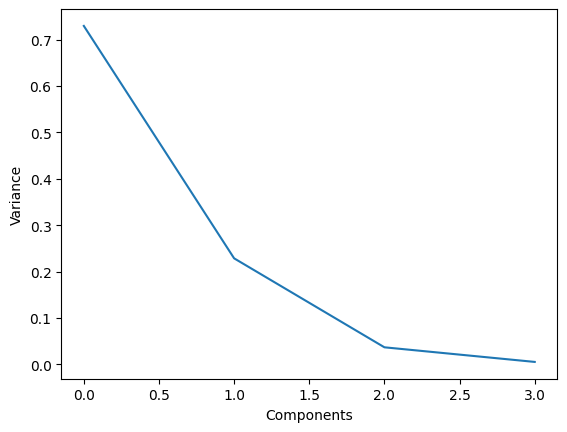

In [ ]:
plt.plot(explained_variance)
plt.xlabel('Components')
plt.ylabel('Variance')
plt.show()

## Reduce to 2D

In [ ]:
pca2 = PCA(n_components=2)
pca_2d = pca2.fit_transform(df_scaled)

## Scatter plot

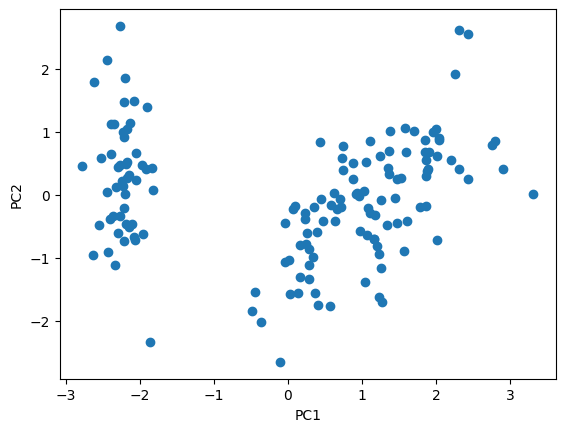

In [ ]:
plt.scatter(pca_2d[:,0], pca_2d[:,1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

## Compute Principal Components (explicit view)

In [ ]:
principal_df = pd.DataFrame(pca_data, columns=[f'PC{i+1}' for i in range(pca_data.shape[1])])
principal_df.head()

,PC1,PC2,PC3,PC4
0,-2.264703,0.480027,0.127706,-0.024168
1,-2.080961,-0.674134,0.234609,-0.103007
2,-2.364229,-0.341908,-0.044201,-0.028377
3,-2.299384,-0.597395,-0.091290,0.065956
4,-2.389842,0.646835,-0.015738,0.035923


## Cumulative Variance Graph

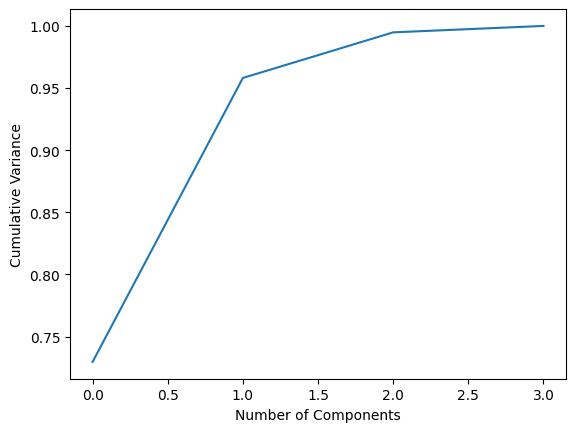

array([0.72962445, 0.95813207, 0.99482129, 1.        ])

In [ ]:
cumulative_variance = explained_variance.cumsum()
plt.plot(cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.show()
cumulative_variance

## Decide Optimal Number of Components

In [ ]:
optimal_components = (cumulative_variance >= 0.9).argmax() + 1
optimal_components

np.int64(2)

## Reduce to 3D (optional comparison)

In [ ]:
pca3 = PCA(n_components=3)
pca_3d = pca3.fit_transform(df_scaled)
pca_3d[:5]

array([[-2.26470281,  0.4800266 ,  0.12770602],
       [-2.08096115, -0.67413356,  0.23460885],
       [-2.36422905, -0.34190802, -0.04420148],
       [-2.29938422, -0.59739451, -0.09129011],
       [-2.38984217,  0.64683538, -0.0157382 ]])

## Compare Original vs Reduced Data Shape

In [ ]:
print('Original shape:', df.shape)
print('2D reduced shape:', pca_2d.shape)
print('3D reduced shape:', pca_3d.shape)

Original shape: (150, 4)
2D reduced shape: (150, 2)
3D reduced shape: (150, 3)


## Analysis: Variance Interpretation

In [ ]:
for i, var in enumerate(explained_variance):
    print(f'PC{i+1} explains {var:.4f} variance')

PC1 explains 0.7296 variance
PC2 explains 0.2285 variance
PC3 explains 0.0367 variance
PC4 explains 0.0052 variance
